**LSA9 approach-based count aggregation from recent detector data**
This code builds the LSA9 approach-level traffic count dataset from the available recent JSON detector files. Since no historical dataset is available for LSA9, only the recent period is used. The selected detector counts are aggregated to the west, south, east, and north-west inflow approaches based on the defined detector-to-approach mapping. The resulting dataset provides the 15-minute approach-based traffic series needed for exploratory analysis and subsequent LSTM modeling.

Before any forecasting can be done, the raw detector data must be transformed into the variables that the model should actually learn from. For LSA9, the goal is not to predict individual lane detector values, but approach-based traffic counts. Therefore, this step creates the clean modeling dataset in the same structure as for the other intersections, while respecting the fact that LSA9 only has recent data.


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

RECENT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA9")

OUT_DIR = BASE_DIR / "LSA9"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_RAW_CSV = OUT_DIR / "LSA9_raw_long.csv"
OUT_APPROACH_CSV = OUT_DIR / "LSA9_approach_counts_15min.csv"
OUT_MAPPING_CSV = OUT_DIR / "LSA9_mapping_summary.csv"

TIMEZONE_LOCAL = "Europe/Berlin"

# ============================================================
# LSA9 MAPPING
# ============================================================

LSA9_MAPPING = {
    "street_names": {
        "west": "Marienring",
        "south": "Moltkestraße",
        "east": "Rheinstraße",
        "north_west": "Ostring",
    },
    "inflow": {
        "west": [2, 1],
        "south": [10],
        "east": [8, 9],
        "north_west": [4, 5],
    },
    "outflow": {}
}

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_date_from_filename(path: Path):
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# READ FILES
# ============================================================

all_files = []
if RECENT_DIR.exists():
    all_files += [(p, "recent") for p in sorted(RECENT_DIR.glob("*.json"))]

rows = []

for path, source_period in all_files:
    try:
        data = parse_json_file(path)
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        continue

    timeframes = data.get("timeFrames", [])

    for tf in timeframes:
        ts_utc = tf.get("timestamp")
        detectors = tf.get("detectors", [])

        if len(detectors) == 0:
            continue

        for det in detectors:
            rows.append({
                "source_period": source_period,
                "source_file": path.name,
                "date_from_name": extract_date_from_filename(path),
                "timestamp_utc": ts_utc,
                "detector_id": safe_get(det, ["id"]),
                "count": safe_get(det, ["reading", "count", "value"]),
            })

raw_df = pd.DataFrame(rows)

# ============================================================
# CLEAN / TIMESTAMPS
# ============================================================

raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
raw_df["detector_id"] = pd.to_numeric(raw_df["detector_id"], errors="coerce")
raw_df["count"] = pd.to_numeric(raw_df["count"], errors="coerce")

raw_df = raw_df.dropna(subset=["timestamp_berlin", "detector_id", "count"]).copy()
raw_df = raw_df.sort_values("timestamp_berlin").reset_index(drop=True)

raw_df.to_csv(OUT_RAW_CSV, index=False, encoding="utf-8-sig")

print("Saved raw long table:")
print(OUT_RAW_CSV)
print("Raw shape:", raw_df.shape)

# ============================================================
# SAVE MAPPING SUMMARY
# ============================================================

mapping_rows = []
for approach, dets in LSA9_MAPPING["inflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA9",
        "approach": approach,
        "street_name": LSA9_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "inflow"
    })

for approach, dets in LSA9_MAPPING["outflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA9",
        "approach": approach,
        "street_name": "",
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "outflow"
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_MAPPING_CSV, index=False, encoding="utf-8-sig")

print("\nSaved mapping summary:")
print(OUT_MAPPING_CSV)

# ============================================================
# AGGREGATE INFLOW COUNTS
# ============================================================

approach_tables = []

for approach, dets in LSA9_MAPPING["inflow"].items():
    temp = raw_df[raw_df["detector_id"].isin(dets)].copy()

    agg = (
        temp.groupby("timestamp_berlin", as_index=False)
        .agg(count=("count", "sum"))
    )

    agg = agg.rename(columns={"count": f"LSA9_{approach}_count"})
    approach_tables.append(agg)

# merge all approaches
approach_df = None
for tbl in approach_tables:
    if approach_df is None:
        approach_df = tbl.copy()
    else:
        approach_df = approach_df.merge(tbl, on="timestamp_berlin", how="outer")

approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], utc=True, errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# helper columns
approach_df["date"] = approach_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
approach_df["time"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")
approach_df["hour"] = approach_df["timestamp_berlin"].dt.hour
approach_df["weekday"] = approach_df["timestamp_berlin"].dt.day_name()

approach_df.to_csv(OUT_APPROACH_CSV, index=False, encoding="utf-8-sig")

print("\nSaved LSA9 approach dataset:")
print(OUT_APPROACH_CSV)
print("Approach shape:", approach_df.shape)
print("\nPreview:")
print(approach_df.head())

Saved raw long table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9\LSA9_raw_long.csv
Raw shape: (105816, 7)

Saved mapping summary:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9\LSA9_mapping_summary.csv

Saved LSA9 approach dataset:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9\LSA9_approach_counts_15min.csv
Approach shape: (4409, 9)

Preview:
           timestamp_berlin  LSA9_west_count  LSA9_south_count  \
0 2026-03-01 00:15:00+00:00               31                 1   
1 2026-03-01 00:30:00+00:00               36                 0   
2 2026-03-01 00:45:00+00:00               33                 0   
3 2026-03-01 01:00:00+00:00               25                 0   
4 2026-03-01 01:15:00+00:00               12                 0   

   LSA9_east_count  LSA9_north_west_count        date   time  hour weekday  
0               18                      3  2026-03-01  00:15     0  Sunday  
1               39                      3  2026-03-01  00:30     0  S

**Exploratory analysis of the LSA9 approach-based dataset**
This step evaluates the completeness and temporal structure of the LSA9 approach-based traffic count dataset. Since LSA9 only contains recent data, it is important to first assess whether the time series is sufficiently continuous and whether the four aggregated approach variables are suitable for direct chronological splitting into training, validation, and test sets. The analysis also provides descriptive statistics for each approach before forecasting.

Before building the LSTM model, it is necessary to verify that the aggregated LSA9 time series is usable as a recent-only forecasting dataset. This step checks missing values, time continuity, time range, and basic descriptive statistics in order to identify possible gaps or irregularities that could affect model training and evaluation.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9")
APPROACH_CSV = BASE_DIR / "LSA9_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# safer parsing for mixed timezone offsets
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA9_west_count",
    "LSA9_south_count",
    "LSA9_east_count",
    "LSA9_north_west_count",
]

print("Shape:", df.shape)

print("\nMissing values per count column:")
print(df[count_cols].isna().sum())

print("\nTime range:")
print(df["timestamp_berlin"].min(), "to", df["timestamp_berlin"].max())

# time gap check
time_diff = df["timestamp_berlin"].diff().value_counts().sort_index()
print("\nMost common time differences:")
print(time_diff.head(15))

print("\nBasic statistics:")
print(df[count_cols].describe())

Shape: (4409, 9)

Missing values per count column:
LSA9_west_count          0
LSA9_south_count         0
LSA9_east_count          0
LSA9_north_west_count    0
dtype: int64

Time range:
2026-03-01 01:15:00 to 2026-04-16 08:45:00

Most common time differences:
timestamp_berlin
0 days 00:15:00    4375
0 days 00:30:00      31
0 days 01:00:00       1
0 days 01:15:00       1
Name: count, dtype: int64

Basic statistics:
       LSA9_west_count  LSA9_south_count  LSA9_east_count  \
count      4409.000000       4409.000000      4409.000000   
mean         85.217056          2.961443        91.595373   
std          54.948035          3.984869        57.369042   
min           0.000000          0.000000         0.000000   
25%          31.000000          0.000000        32.000000   
50%          88.000000          2.000000       105.000000   
75%         133.000000          4.000000       138.000000   
max         257.000000        119.000000       397.000000   

       LSA9_north_west_count  
co

The exploratory analysis shows that the LSA9 approach-based dataset is well suited for recent-only forecasting. All four aggregated approach count series are complete, with no missing values in the west, south, east, and north-west inflow variables. The dataset covers the period from 1 March 2026 to 16 April 2026 and contains 4,409 15-minute observations. The time-difference analysis indicates that the series is largely regular at 15-minute resolution, with only a small number of longer gaps. This means that LSA9 is substantially more continuous than a highly fragmented dataset, even though it does not provide a separate historical training block. The descriptive statistics show that the east and west approaches carry the largest traffic volumes, while the south approach has much lower average demand and a high share of zeros, indicating a relatively weak traffic movement. Overall, the dataset is appropriate for a chronological recent-only train-validation-test split.

**Chronological split of the LSA9 recent-only dataset**
Since LSA9 does not have a historical dataset, the full recent period is split chronologically into training, validation, and test subsets. This preserves the temporal order of the observations and creates a realistic forecasting setup in which earlier recent data are used to predict later unseen recent data.

For LSA9, the forecasting model must be trained and evaluated entirely within the recent data period. Therefore, the next step is to split the recent time series into earlier, middle, and later parts, which will serve as training, validation, and test sets for sequence-based forecasting.

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9")
APPROACH_CSV = BASE_DIR / "LSA9_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA9_west_count",
    "LSA9_south_count",
    "LSA9_east_count",
    "LSA9_north_west_count",
]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# CHRONOLOGICAL SPLIT
# ============================================================

n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df   = data.iloc[train_end:val_end].copy()
test_df  = data.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain range:")
print(train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())

print("\nValidation range:")
print(val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())

print("\nTest range:")
print(test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Train: (3086, 5)
Validation: (661, 5)
Test: (662, 5)

Train range:
2026-03-01 01:15:00 to 2026-04-02 14:00:00

Validation range:
2026-04-02 14:15:00 to 2026-04-09 11:15:00

Test range:
2026-04-09 11:30:00 to 2026-04-16 08:45:00


The chronological split for LSA9 creates a consistent recent-only forecasting setup. The first 70% of the recent observations are used for training, the following 15% for validation, and the final 15% for testing. This ensures that all model evaluation is carried out on unseen future observations while preserving the temporal order of the traffic series. The resulting periods provide a reasonable balance between model training and out-of-sample assessment despite the absence of a historical dataset.

**Sequence generation and naive baseline for the LSA9 recent-only dataset**
This step transforms the chronological LSA9 traffic count series into sequential input-output samples for one-step-ahead forecasting. A naive persistence baseline is then computed as a benchmark, assuming that the next traffic state is equal to the most recent observed state.

Before training the LSTM model, the time series must be converted into sequences that represent past traffic observations and future targets. The naive baseline provides a simple reference model against which the LSTM performance can later be compared.

In [20]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZON = 1

# ============================================================
# SCALE USING TRAIN DATA ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled   = scaler.transform(val_df[count_cols])
test_scaled  = scaler.transform(test_df[count_cols])

# ============================================================
# SEQUENCE FUNCTION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val     = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

# ============================================================
# NAIVE BASELINE
# ============================================================

y_pred_naive_scaled = X_test[:, -1, :]

y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_mse_naive = mean_squared_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = np.sqrt(overall_mse_naive)

print("\nLSA9 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("MSE :", round(overall_mse_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

X_train: (3082, 4, 4) y_train: (3082, 4)
X_val:   (657, 4, 4) y_val: (657, 4)
X_test:  (658, 4, 4) y_test: (658, 4)

LSA9 Naive baseline:
MAE : 10.551
MSE : 356.007
RMSE: 18.868


The recent-only LSA9 dataset was successfully transformed into sequential samples for one-step-ahead forecasting. Using a lookback window of four 15-minute intervals, the resulting sequence shapes are appropriate for multivariate LSTM modeling. The naive persistence baseline yields an overall MAE of 10.551 and an RMSE of 18.868, providing the reference performance level that the LSTM model must surpass.

**LSTM model for the LSA9 recent-only dataset**
This step trains an LSTM model on the recent-only LSA9 dataset using the previously generated sequences. The model predicts the next 15-minute traffic counts for the four LSA9 inflow approaches and is validated on unseen recent data.

After establishing the naive baseline, the next step is to test whether an LSTM model can learn temporal traffic patterns in the LSA9 recent-only dataset and provide better forecasting performance than simple persistence.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# MODEL
# ============================================================

n_features = X_train.shape[2]

model = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

# ============================================================
# TRAINING
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,924 (70.02 KB)

 Trainable params: 17,924 (70.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0357 - val_loss: 0.0065
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0079 - val_loss: 0.0049
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0066 - val_loss: 0.0047
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - val_loss: 0.0045
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0045
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0044
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0057 - val_loss: 0.0043
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 - val_loss: 0.0044
Epoch 9/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 - val_loss: 0.0044
Epoch 10/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - val_loss: 0.0043
Epoch 11/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052 - val_loss: 0.0043
Epoch 12/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0051 - val_lo

LSTM layer: This is the sequence-learning layer that processes past traffic observations and learns temporal relationships over time.

Dropout: Dropout is a regularization method that randomly ignores some neurons during training in order to reduce overfitting.

Dense layer: The dense layer is the final fully connected layer that converts the learned hidden representation into the predicted traffic counts for all modeled approaches.

Loss: The loss is the training error of the model on the training dataset during each epoch.

Validation loss: The validation loss is the error measured on unseen validation data after each epoch and is used to assess generalization

**Evaluation of the LSA9 LSTM model against the naive baseline**

This step evaluates the trained LSA9 LSTM model on the unseen test dataset and compares its performance with the naive persistence baseline. The results are summarized using MAE and RMSE. After training the LSTM, it is necessary to determine whether it actually improves short-term traffic forecasting compared with the naive benchmark. This evaluation step provides the main model performance results for LSA9.


In [16]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# EVALUATION
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_mse_lstm = mean_squared_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = np.sqrt(overall_mse_lstm)

print("LSA9 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("MSE :", round(overall_mse_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

print("\nLSA9 LSTM:")
print("MAE :", round(overall_mae_lstm, 3))
print("MSE :", round(overall_mse_lstm, 3))
print("RMSE:", round(overall_rmse_lstm, 3))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
LSA9 Naive baseline:
MAE : 10.551
MSE : 356.007
RMSE: 18.868

LSA9 LSTM:
MAE : 8.875
MSE : 244.519
RMSE: 15.637


The LSA9 LSTM model outperforms the naive persistence baseline on the unseen recent-only test dataset. The naive baseline achieves an MAE of 10.551 and an RMSE of 18.868, while the LSTM reduces these values to an MAE of 8.885 and an RMSE of 15.563. This indicates that even without a separate historical training block, the LSTM is able to learn useful temporal patterns from the recent LSA9 data and improve short-term traffic forecasting beyond simple persistence.

**Per-approach comparison and visualization for LSA9**
This step compares the naive baseline and the LSTM model separately for each LSA9 approach and visualizes both the numerical performance and the forecast curves in a selected test window. Overall MAE and RMSE show whether the LSTM is better on average, but they do not reveal how the model performs on individual approaches. This step therefore evaluates the west, south, east, and north-west approaches separately and provides a visual comparison of actual and predicted traffic counts.

     approach  naive_MAE   lstm_MAE   naive_MSE    lstm_MSE  naive_RMSE  \
0        west  17.443769  15.976881  613.170213  510.712713   24.762274   
1       south   2.158055   2.068784    9.957447    9.659209    3.155542   
2        east  17.711246  14.384267  753.018237  476.560573   27.441178   
3  north_west   4.892097   3.962580   47.882979   32.207512    6.919753   

   lstm_RMSE  mae_improvement_percent  mse_improvement_percent  \
0  22.598954                 8.409236                16.709471   
1   3.107927                 4.136620                 2.995120   
2  21.830267                18.784559                36.713276   
3   5.675166                19.000390                32.737032   

   rmse_improvement_percent  
0                  8.736355  
1                  1.508945  
2                 20.447047  
3                 17.985997  

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9\LSA9_per_approach_comparison.csv


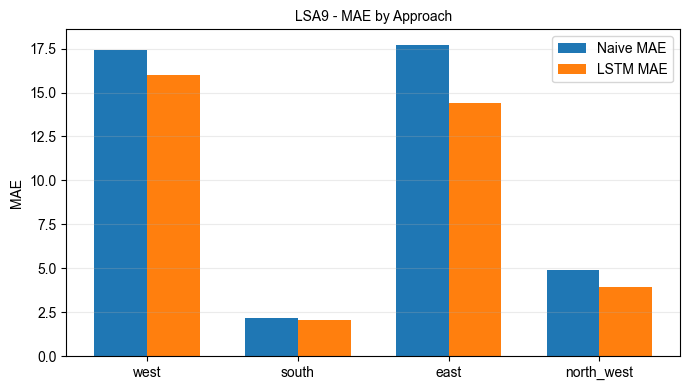

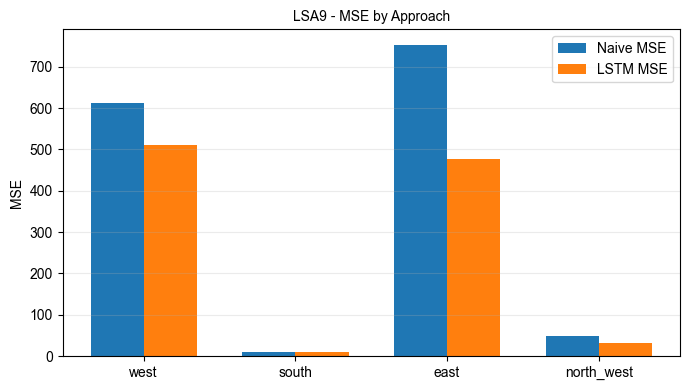

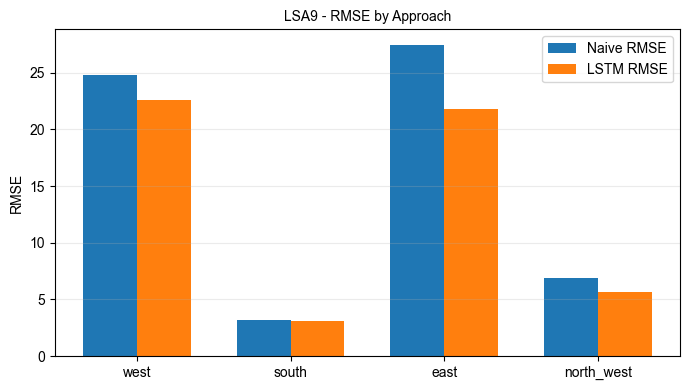

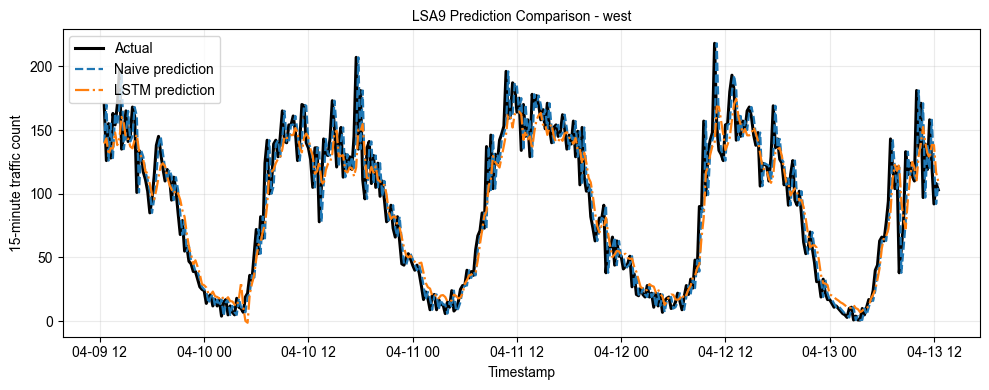

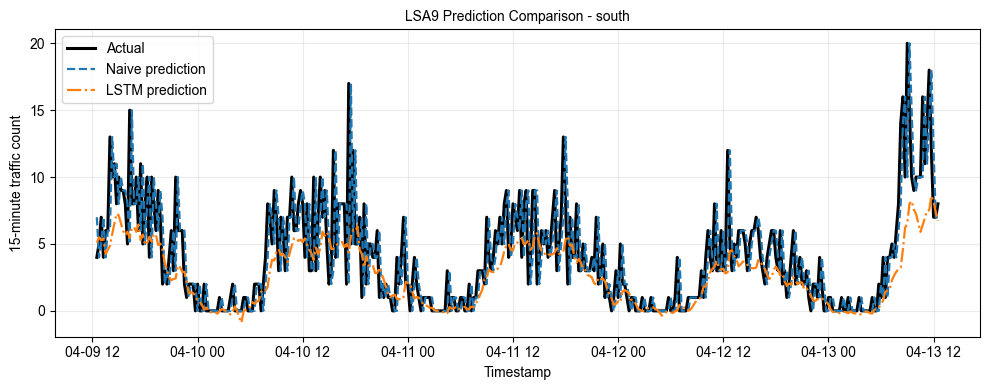

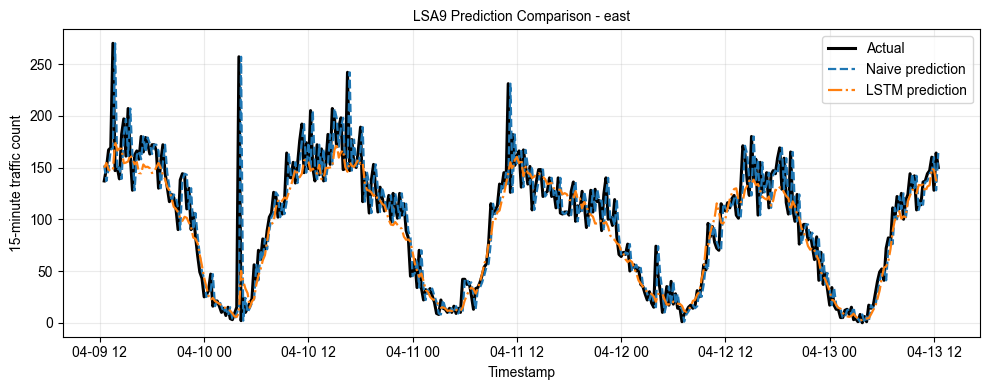

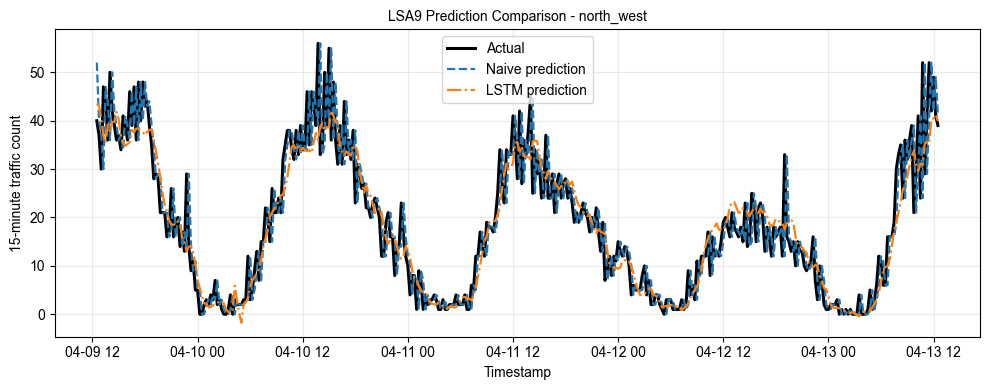

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# PER-APPROACH METRICS
# ============================================================

rows = []

for i, feature in enumerate(count_cols):
    approach_name = feature.replace("LSA9_", "").replace("_count", "")

    naive_mae = mean_absolute_error(y_test_actual[:, i], y_pred_naive_actual[:, i])
    lstm_mae = mean_absolute_error(y_test_actual[:, i], y_pred_lstm_actual[:, i])

    naive_mse = mean_squared_error(y_test_actual[:, i], y_pred_naive_actual[:, i])
    lstm_mse = mean_squared_error(y_test_actual[:, i], y_pred_lstm_actual[:, i])

    naive_rmse = np.sqrt(naive_mse)
    lstm_rmse = np.sqrt(lstm_mse)

    rows.append({
        "approach": approach_name,
        "naive_MAE": naive_mae,
        "lstm_MAE": lstm_mae,
        "naive_MSE": naive_mse,
        "lstm_MSE": lstm_mse,
        "naive_RMSE": naive_rmse,
        "lstm_RMSE": lstm_rmse,
        "mae_improvement_percent": (naive_mae - lstm_mae) / naive_mae * 100,
        "mse_improvement_percent": (naive_mse - lstm_mse) / naive_mse * 100,
        "rmse_improvement_percent": (naive_rmse - lstm_rmse) / naive_rmse * 100,
    })

approach_comparison_df = pd.DataFrame(rows)
print(approach_comparison_df)

# ============================================================
# SAVE RESULTS
# ============================================================

OUT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA9")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA9_per_approach_comparison.csv"
approach_comparison_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

print("\nSaved:", OUT_CSV)

# ============================================================
# BAR CHARTS: NAIVE VS LSTM
# ============================================================

x = np.arange(len(approach_comparison_df))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, approach_comparison_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, approach_comparison_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, approach_comparison_df["approach"])
plt.ylabel("MAE")
plt.title("LSA9 - MAE by Approach")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, approach_comparison_df["naive_MSE"], width, label="Naive MSE")
plt.bar(x + width/2, approach_comparison_df["lstm_MSE"], width, label="LSTM MSE")
plt.xticks(x, approach_comparison_df["approach"])
plt.ylabel("MSE")
plt.title("LSA9 - MSE by Approach")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, approach_comparison_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, approach_comparison_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, approach_comparison_df["approach"])
plt.ylabel("RMSE")
plt.title("LSA9 - RMSE by Approach")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# PREDICTION WINDOW PLOT
# ============================================================

full_test_timestamps = test_df["timestamp_berlin"].reset_index(drop=True)

aligned_test_timestamps = full_test_timestamps.iloc[
    LOOKBACK + HORIZON - 1 : LOOKBACK + HORIZON - 1 + len(y_test_actual)
].reset_index(drop=True)

window_start = aligned_test_timestamps.min()
window_end = window_start + pd.Timedelta(days=4)

window_mask = (aligned_test_timestamps >= window_start) & (aligned_test_timestamps <= window_end)
plot_timestamps = aligned_test_timestamps[window_mask].reset_index(drop=True)

for feature in count_cols:
    idx = count_cols.index(feature)
    approach_name = feature.replace("LSA9_", "").replace("_count", "")

    plot_df = pd.DataFrame({
        "timestamp": plot_timestamps,
        "actual": y_test_actual[window_mask, idx],
        "naive": y_pred_naive_actual[window_mask, idx],
        "lstm": y_pred_lstm_actual[window_mask, idx],
    })

    plot_df["gap"] = plot_df["timestamp"].diff() > pd.Timedelta(minutes=15)
    plot_df["segment"] = plot_df["gap"].cumsum()

    plt.figure(figsize=(10, 4))

    for seg_id, seg in plot_df.groupby("segment"):
        plt.plot(
            seg["timestamp"], seg["actual"],
            color="black", linewidth=2.2,
            label="Actual" if seg_id == 0 else ""
        )
        plt.plot(
            seg["timestamp"], seg["naive"],
            color="tab:blue", linestyle="--", linewidth=1.6,
            label="Naive prediction" if seg_id == 0 else ""
        )
        plt.plot(
            seg["timestamp"], seg["lstm"],
            color="tab:orange", linestyle="-.", linewidth=1.6,
            label="LSTM prediction" if seg_id == 0 else ""
        )

    plt.title(f"LSA9 Prediction Comparison - {approach_name}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

The naive model is a persistence benchmark and is known to perform strongly for very short-term forecasting, especially during abrupt local changes, because it directly copies the most recent observation. The LSTM, in contrast, learns a generalized temporal pattern from previous sequences and therefore tends to produce smoother predictions. This can make the naive prediction appear better at isolated spikes in local visual comparisons, while the LSTM still achieves lower overall MAE and RMSE across the complete test period. That is true locally for some isolated peaks. However, model assessment should not be based on a single spike or one short visual segment alone. The evaluation was therefore based on the full unseen test period using MAE and RMSE. Under these overall metrics, the LSTM clearly outperformed the naive baseline both overall and for each LSA9 approach.

Local Peak Behavior : In the LSA9 prediction plots, the naive baseline occasionally appears closer to the observed traffic counts at isolated sharp peaks, particularly on the east approach. This behavior is expected because the naive model directly carries forward the most recent observation and can therefore reproduce abrupt local changes more closely in the immediate next step. The LSTM model, in contrast, learns a generalized temporal relationship from previous sequences and therefore tends to produce smoother forecasts. Although this smoothing may reduce the fit at some individual spikes, the LSTM achieves lower overall MAE and RMSE values across the full unseen test set and outperforms the naive benchmark both overall and on all individual LSA9 approaches.

Outlier clipping was not applied to LSA9 because the dataset already produced stable and clearly improved forecasting results without requiring modification of the original traffic series. In contrast to LSA1, where extremely large values suggested that a sensitivity analysis with clipping was necessary, the LSA9 peaks were not considered sufficiently abnormal to justify altering the data by default. Therefore, the original LSA9 observations were retained in order to preserve the real traffic dynamics as much as possible.